In [36]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

load dataset

In [37]:
df = pd.read_csv("Mall_Customers.csv")

select features

In [38]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

elbow method

In [39]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)
    inertia.append(model.inertia_)

plot elbow curve

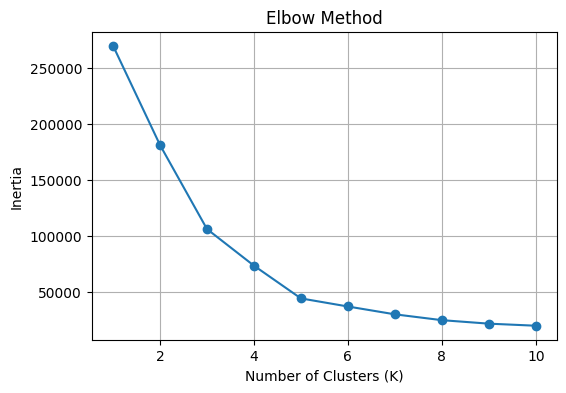

In [40]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


k-means clustering

In [41]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [42]:
df["Cluster"] = kmeans.labels_


In [43]:
print("Cluster Centers:\n")
print(kmeans.cluster_centers_)


Cluster Centers:

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [44]:
print("\nCustomer Segmentation:\n")
print(df)


Customer Segmentation:

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1    Male   19                  15                      39   
1             2    Male   21                  15                      81   
2             3  Female   20                  16                       6   
3             4  Female   23                  16                      77   
4             5  Female   31                  17                      40   
..          ...     ...  ...                 ...                     ...   
195         196  Female   35                 120                      79   
196         197  Female   45                 126                      28   
197         198    Male   32                 126                      74   
198         199    Male   32                 137                      18   
199         200    Male   30                 137                      83   

     Cluster  
0          4  
1          2  
2          4  
3 

visualization

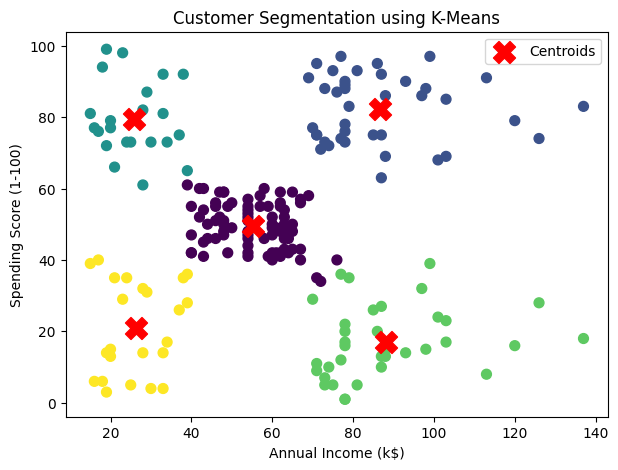

In [45]:
plt.figure(figsize=(7,5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()